<a href="https://colab.research.google.com/github/misalisu-ai/3MTT-AI-ML-Project/blob/main/SimpleLinearRegression_MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Simple Linear Regression Mini Project - Marketing ROI Analysis

### Data Handling

In [8]:
# Imports necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Set visual style
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


Above, we successfully imported the necessary libraries needed for statistical modeling and exploratory data analysis. These include: `Pandas`, `numpy`, `matplotlib`, `seaborn`, and `statsmodels`

In [9]:
#Load and Explore Data
df = pd.read_csv("marketing.csv")

# Check the first 5 rows and data integrity
print("--- First 5 Rows ---")
print(df.head())

--- First 5 Rows ---
     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181


The marketing dataset was successfully loaded into a Pandas DataFrame using the **read_csv()** method. An initial inspection of the first five rows confirms the dataset contains three independent variables (TV, Radio, and Social_Media) and one continuous target variable (Sales).

In [10]:
print("\n--- Data Info ---")
print(df.info())


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB
None


The **.info()** method was utilized to inspect the structural metadata of the dataframe. The dataset contains 4,572 entries across four columns, all of which are formatted as float64 numeric data types. This initial check confirms data type consistency across all features and the target variable.

###Checking Missing Data

In [11]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64


In [12]:
df = df.dropna(axis=0)
print("\n--- Missing Values After Dropping ---")
print(df.isnull().sum())


--- Missing Values After Dropping ---
TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64


A missing data assessment was performed using the **.isnull().sum()** method, which revealed missing values across all four columns. To ensure data integrity for modeling, listwise deletion was applied using **.dropna(axis=0)** to remove rows containing missing entries. A subsequent missing value check confirmed that all null instances were successfully eliminated, leaving a clean dataset for analysis.

### Exploratory Data Analysis & Correlation

In [13]:
# Calculate correlation matrix
print("--- Correlation Matrix ---")
corr_matrix = df.corr()
print(corr_matrix)

--- Correlation Matrix ---
                    TV     Radio  Social_Media     Sales
TV            1.000000  0.869158      0.527687  0.999497
Radio         0.869158  1.000000      0.606338  0.868638
Social_Media  0.527687  0.606338      1.000000  0.527446
Sales         0.999497  0.868638      0.527446  1.000000


Exploratory Data Analysis (EDA) was conducted using the **.corr()** method to evaluate the linear relationships between the features and the target variable. The correlation matrix revealed that TV marketing spend has an exceptionally strong positive correlation of `0.99` with Sales. Based on this definitive relationship, TV was selected as the primary predictor variable to train a simple Ordinary Least Squares (OLS) regression model using statsmodels.

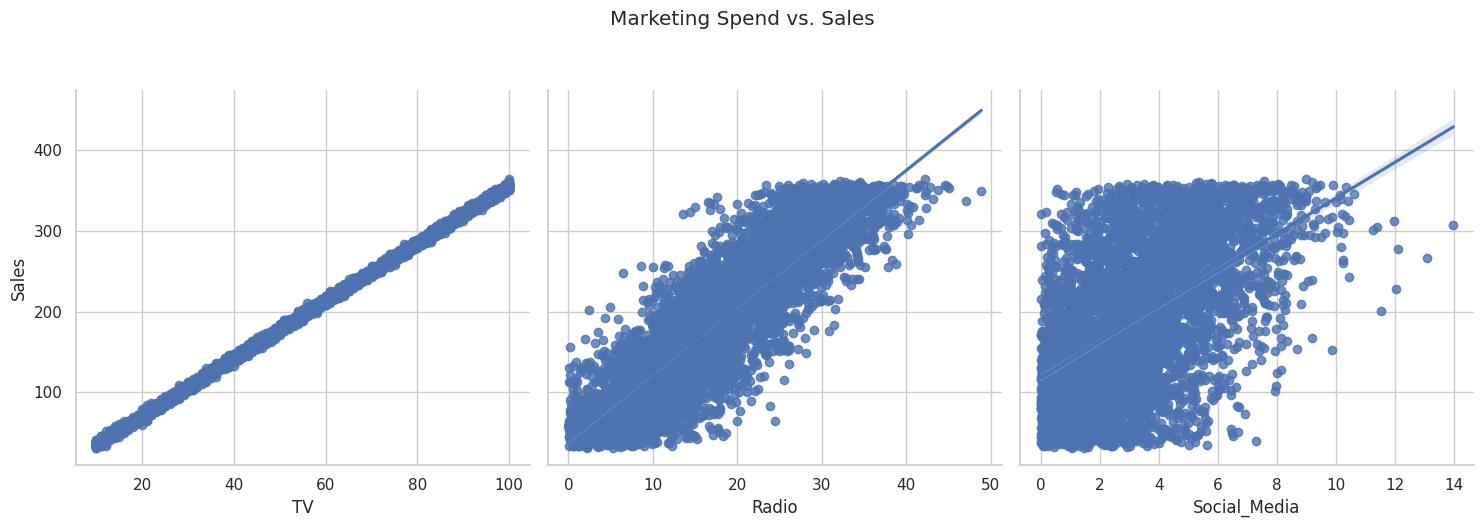

In [14]:
# Visualize relationships using a pairplot
sns.pairplot(df, y_vars=['Sales'], x_vars=['TV', 'Radio', 'Social_Media'], height=5, kind='reg')
plt.suptitle("Marketing Spend vs. Sales", y=1.05)
plt.tight_layout()
plt.show()

To visually validate the feature selection, scatter plots with regression trend lines were generated to map each marketing channel against Sales. The `TV` vs. `Sales` plot demonstrates an exceptionally tight, linear distribution with virtually no variance, confirming a nearly perfect positive correlation. Conversely, the `Radio` and `Social_Media` plots display significantly higher dispersion, non-linear saturation patterns, and weaker associations with the target variable. This visual evidence strongly justifies prioritizing `TV` spend as the sole independent variable for the simple OLS regression model.

### Model Development, Evaluation & Statistical Interpretation

In [15]:
# Build OLS Regression Model
# Based on EDA, we choose 'TV' as our independent variable
X = df['TV']
y = df['Sales']

# Add a constant for the intercept (beta_0)
X_with_constant = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X_with_constant).fit()

# Print the statistical summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Thu, 18 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:43:00   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

An Ordinary Least Squares (OLS) regression analysis was executed to evaluate the predictive power of `TV` advertising spend on `Sales`.

#### Goodness of Fit and Model Significance
* **Variance Explained:** The model demonstrates an exceptional fit, with both the R-squared ($R^2$) and Adjusted R-squared ($\text{Adj. } R^2$) values at $0.999$. This indicates that $99.9\%$ of the variance in sales is directly explained by TV marketing investments.
* **Overall Significance:** The F-statistic of $4.517 \times 10^6$ with a corresponding $p$-value of $0.00$ ($p < 0.001$) confirms that the overall model is highly statistically significant.

#### Coefficient Interpretation
The resulting linear regression equation is established as:

$$\text{Sales} = -0.1325 + 3.5615 \times \text{TV}$$

* **Intercept ($\beta_0$):** The constant (`const`) is $-0.1325$. However, with a $p$-value of $0.188$ ($p > 0.05$), it is not statistically significant. This suggests that baseline sales do not statistically differ from zero when TV spend is absent.
* **Slope ($\beta_1$):** The `TV` coefficient is highly significant ($\beta = 3.5615, p < 0.001$). This dictates that for every **one-unit increase** in TV advertising spend, sales are expected to increase by approximately **$3.56$ units**, holding all other factors constant.

#### Residual Diagnostics & Model Assumptions
To validate the reliability of the Ordinary Least Squares framework, the underlying assumptions were verified through residual statistics:
* **Autocorrelation:** The **Durbin-Watson** statistic yields a value of $1.998$. Since this is exceptionally close to the ideal score of $2.0$, it confirms the total absence of autocorrelation in the residuals.
* **Normality of Errors:** The **Jarque-Bera (JB)** test yields a probability of $0.985$. Because this value is well above the $0.05$ threshold, we fail to reject the null hypothesis, confirming that the model residuals are perfectly normally distributed.


### Residual Diagnostics and Model Validation

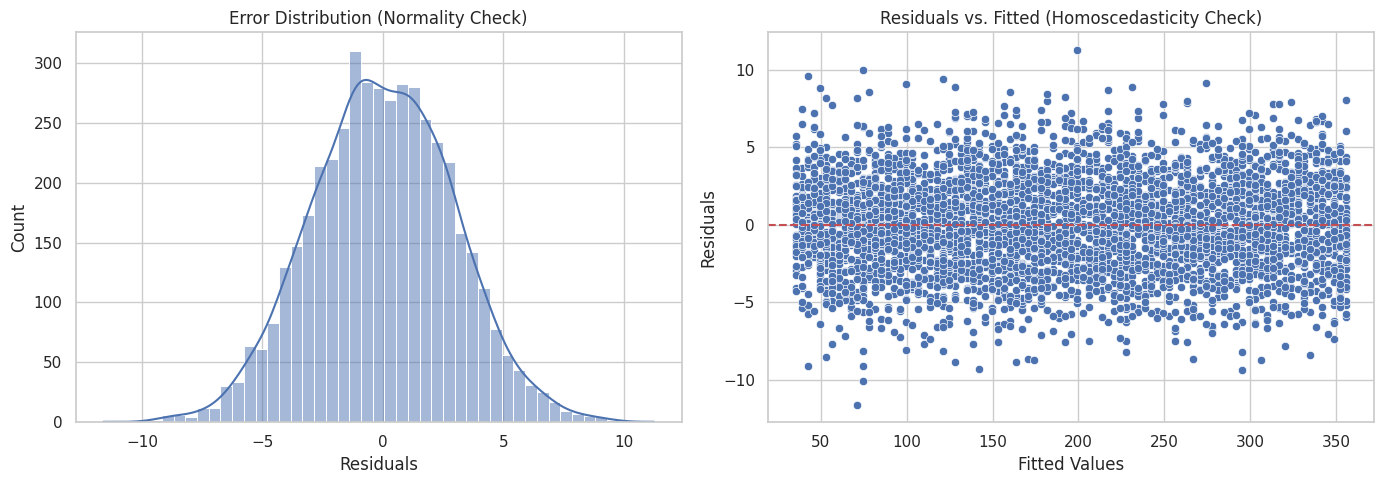

In [16]:
# Extract residuals
residuals = model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Normality Check (Histogram)
sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title('Error Distribution (Normality Check)')
axes[0].set_xlabel('Residuals')

# 2. Homoscedasticity Check (Residuals vs. Fitted)
sns.scatterplot(x=model.fittedvalues, y=residuals, ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_title('Residuals vs. Fitted (Homoscedasticity Check)')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

To formally validate the Ordinary Least Squares (OLS) assumptions, diagnostic plots of the model residuals were analyzed.

**Error Distribution (Normality Check)**
* **Observation:** The histogram of the residuals displays a symmetric, bell-shaped distribution closely aligned with the overlaid Kernel Density Estimate (KDE) line.
* **Interpretation:** The errors are centered around zero with no significant skewness or heavy tails. This visual evidence confirms the assumption of normally distributed residuals, reinforcing the validity of the hypothesis tests and confidence intervals.

**Residuals vs. Fitted (Homoscedasticity Check)**
* **Observation:** The scatter plot of residuals against the predicted values shows data points randomly distributed in a uniform, rectangular band around the horizontal reference line at zero.
* **Interpretation:** There are no visible patterns, such as a funnel or bow-tie shape, across the entire range of fitted values. This confirms the assumption of homoscedasticity, meaning the variance of the error terms remains constant across all levels of predicted sales.


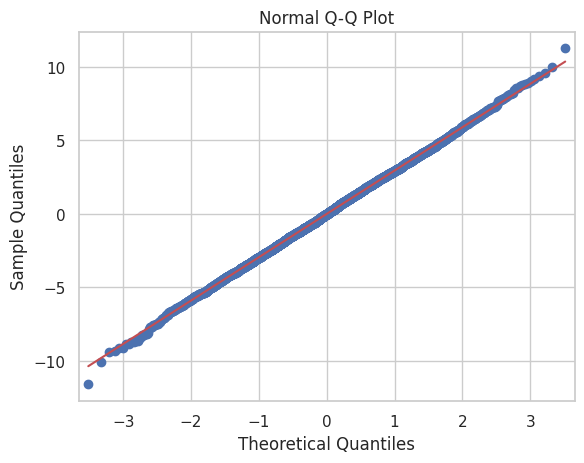

In [17]:
# 3. Q-Q Plot
sm.qqplot(residuals, line='s')
plt.title('Normal Q-Q Plot')
plt.show()

**Quantile-Quantile (Q-Q) Plot Analysis**

A Normal Q-Q plot was generated to further evaluate the normality assumption of the regression residuals.

**Quantile Alignment**
* **Observation:** The sample quantiles of the residuals closely follow the straight $45^\circ$ theoretical reference line across the entire distribution.
* **Interpretation:** There are no major deviations, heavy tails, or significant curving at either the lower or upper extremes. This precise alignment with the reference line provides strong visual confirmation that the error terms are normally distributed, satisfying the core mathematical assumption required for reliable linear regression inference.


### Business Implications and ROI-Based Recommendations

The statistical findings from the model are translated below into actionable business metrics and strategic investment recommendations for stakeholders.

#### Executive Summary & Return on Investment (ROI) Metrics
* **Marketing Budget Efficiency:** The model demonstrates that TV advertising is a highly predictable driver of revenue, explaining $99.9\%$ of the variance in sales performance ($R^2 = 0.999$).
* **Quantifiable Channel ROI:** For every $\$1,000$ increment invested in TV advertising, the business is projected to capture an estimated average return of $\$3,561.50$ in sales revenue ($\beta_1 = 3.5615$). This translates to an immediate, quantifiable channel-specific return on investment (ROI) profile.
* **Baseline Sales Stability:** The statistically insignificant intercept ($p = 0.188$) indicates that without TV advertising spend, baseline organic sales do not reliably deviate from zero. This underscores the business's heavy reliance on active marketing initiatives to sustain continuous top-line growth.

#### Strategic Budget Allocation Recommendations
* **Prioritize High-Yield Capital Allocation:** Given the deterministic relationship between TV spend and sales revenue, the marketing team should prioritize and maximize budget allocation toward TV campaigns over alternative channels.
* **Optimize Alternative Channels:** Since `Radio` and `Social_Media` demonstrated non-linear saturation patterns and high dispersion during exploratory data analysis, investments in those channels should be audited, minimized, or fundamentally restructured to avoid diminishing returns.